In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge,Lasso
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error


In [2]:
df = pd.read_csv("complated_clean_data.csv")

In [3]:
df.head(5)

,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,0.876693,1.989608,1.008484,0.925295,-0.038259,-1.447797,-1.108065,-0.948655,0.303668,35154898
1,1.238767,1.230524,1.008484,-0.704701,0.619638,-0.330404,0.902474,1.054124,-0.664835,26710893
2,-1.155940,-0.287644,0.106553,-0.355416,-1.354054,2.282091,-1.108065,1.054124,-0.093667,11216242
3,0.109526,0.471440,0.106553,0.284939,0.525653,-0.141549,-1.108065,-0.948655,-0.471135,21984310
4,0.064715,0.471440,1.008484,2.031364,0.995579,-1.825507,-1.108065,1.054124,-0.193000,25080429


In [4]:
x = df.drop('house_price_inr',axis=1)
y = df['house_price_inr']

In [5]:
from sklearn.model_selection import train_test_split,KFold,cross_val_score

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
len(x_train)

2871

In [8]:
len(x_test)

718

In [9]:
r = Ridge(alpha=0.0001)

In [10]:
r.fit(x_train,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",Non

In [11]:
p_test = r.predict(x_test) 

In [12]:
result = pd.DataFrame({
    'accual_values_price' : y_test.values,
    'predicted_house_price' : p_test
})

result

,accual_values_price,predicted_house_price
0,32691574,3.003169e+07
1,25525240,2.739702e+07
2,22740225,2.063458e+07
3,12718440,1.557661e+07
4,20657437,2.214711e+07
...,...,...
713,16954740,1.845919e+07
714,13520657,1.489730e+07
715,19403671,1.811641e+07
716,4225646,-7.491164e+05


In [13]:
score = r2_score(y_test,p_test) * 100
print(f"r2 score : {score}")

r2 score : 91.02439032761417


In [14]:
p_train = r.predict(x_train) 

In [15]:
result = pd.DataFrame({
    'accual_values_price' : y_train.values,
    'predicted_house_price' : p_train
})

result

,accual_values_price,predicted_house_price
0,11996712,1.358849e+07
1,17020376,1.497467e+07
2,35531361,3.113441e+07
3,12257583,1.178471e+07
4,15698338,1.677672e+07
...,...,...
2866,26365052,2.631274e+07
2867,28146348,2.672334e+07
2868,34377748,3.331362e+07
2869,18941578,1.973240e+07


In [16]:
score_train = r2_score(y_train,p_train) * 100
print(f"r2 score : {score_train}")

r2 score : 91.44817679045725


In [17]:
mae = mean_absolute_error(y_test,p_test)
print(f"mean absolute error : {mae}")

mean absolute error : 1876064.3062302535


In [18]:
mse = mean_squared_error(y_test,p_test)
print(f"mean squared error : {mse}")


mean squared error : 5861972049605.741


In [19]:
kf = KFold(n_splits=5,random_state=42,shuffle=True)

In [20]:
cross_score = cross_val_score(r,x,y,cv=kf,scoring='r2')

In [21]:
print(cross_score)

[0.9102439  0.9134429  0.91489618 0.91687121 0.90894173]


In [22]:
avg_score = cross_score.mean()
print(f"Avrage score : {avg_score}")

Avrage score : 0.91287918464276


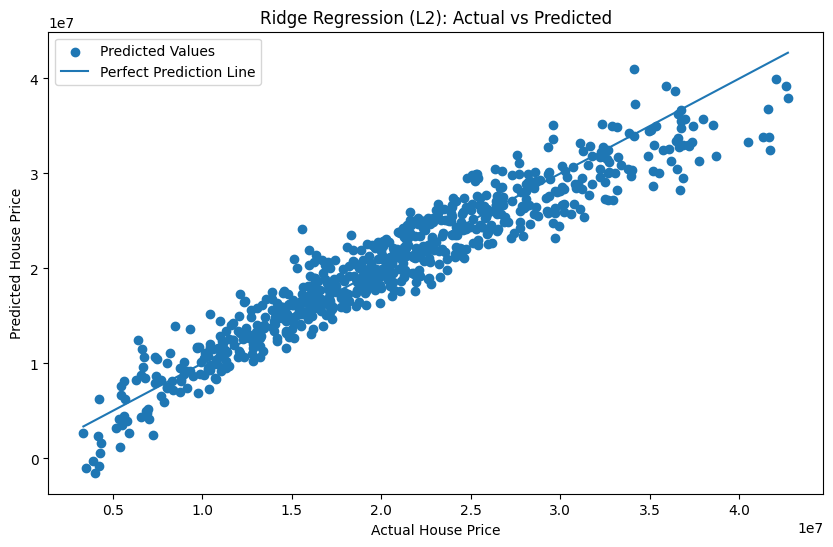

In [23]:
# =====================================
# Ridge Regression Final Graph
# =====================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    p_test,
    label='Predicted Values'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    label='Perfect Prediction Line'
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Ridge Regression (L2): Actual vs Predicted")

plt.legend()

plt.show()

## Ridge Regression (L2) Graph Interpretation

### Graph Analysis: Actual vs Predicted House Price

The graph above represents the relationship between the **actual house prices** and the **predicted house prices** generated by the Ridge Regression (L2) model.

### Observation

- Most prediction points are positioned close to the **Perfect Prediction Line**.
- The predicted values follow the actual values with a strong positive relationship.
- Only small deviations from the diagonal line are observed, indicating lower prediction errors.
- The prediction pattern is stable across different house price ranges.

### Interpretation

Ridge Regression applies **L2 regularization**, which helps reduce model complexity by shrinking coefficient values and minimizing overfitting. The graph indicates that the model effectively captures the relationship between the input variables and the target variable.

### Conclusion

✅ Predictions closely follow actual values  
✅ Low prediction error observed  
✅ Very low overfitting detected  
✅ Excellent generalization capability  
✅ Stable and consistent performance across different data points  

Therefore, the **Ridge Regression (L2) model can be considered a good and reliable model for house price prediction**.

# Final Conclusion – Ridge Regression

| Metric | Value | Interpretation |
|----------|--------|----------------|
| Training R² Score | 91.45% | Model learned training data effectively |
| Testing R² Score | 91.02% | Strong prediction performance on unseen data |
| Average Cross Validation Score | 91.29% | Stable and reliable model performance |
| MAE | 1,876,064.31 | Average prediction error |
| MSE | 5,861,972,049,605.74 | Squared prediction error |
| Train-Test Difference | 0.42% | Extremely small difference indicates excellent generalization |
| Model Performance | Excellent |
| Overfitting Status | Very Low |

## Model Status

✅ Good Model  
❌ Worst Model: No

## Final Business Conclusion

The Ridge Regression model achieved a training score of **91.45%** and a testing score of **91.02%**. The average cross-validation score of **91.29%** indicates stable and consistent performance across multiple folds. The difference between training and testing scores is only **0.42%**, which indicates very low overfitting and excellent generalization ability. Therefore, the Ridge Regression model is considered a reliable and effective model for house price prediction on unseen data.

In [24]:
l = Lasso(alpha=0.01)

In [25]:
l.fit(x_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [26]:
p_test_l = l.predict(x_test) 

In [27]:
result = pd.DataFrame({
    'accual_values_price' : y_test.values,
    'predicted_house_price' : p_test_l
})

result

,accual_values_price,predicted_house_price
0,32691574,3.003169e+07
1,25525240,2.739702e+07
2,22740225,2.063458e+07
3,12718440,1.557661e+07
4,20657437,2.214711e+07
...,...,...
713,16954740,1.845919e+07
714,13520657,1.489730e+07
715,19403671,1.811641e+07
716,4225646,-7.491171e+05


In [28]:
score_l = r2_score(y_test,p_test_l) * 100
print(f"r2 score : {score_l}")

r2 score : 91.02439069307985


In [29]:
p_train_l = l.predict(x_train) 

In [30]:
result_l = pd.DataFrame({
    'accual_values_price' : y_train.values,
    'predicted_house_price' : p_train_l
})

result_l

,accual_values_price,predicted_house_price
0,11996712,1.358849e+07
1,17020376,1.497467e+07
2,35531361,3.113441e+07
3,12257583,1.178471e+07
4,15698338,1.677672e+07
...,...,...
2866,26365052,2.631274e+07
2867,28146348,2.672334e+07
2868,34377748,3.331362e+07
2869,18941578,1.973240e+07


In [31]:
score_train_l = r2_score(y_train,p_train) * 100
print(f"r2 score : {score_train}")

r2 score : 91.44817679045725


In [32]:
mae = mean_absolute_error(y_test,p_test_l)
print(f"mean absolute error : {mae}")

mean absolute error : 1876064.2876146338


In [33]:
mse = mean_squared_error(y_test,p_test_l)
print(f"mean squared error : {mse}")

mean squared error : 5861971810920.048


In [34]:
kf_l = KFold(n_splits=5,random_state=42,shuffle=True)

In [35]:
cross_score_l = cross_val_score(l,x,y,cv=kf,scoring='r2')

In [36]:
print(cross_score_l)

[0.91024391 0.9134429  0.91489618 0.91687121 0.90894173]


In [37]:
avg_score_l = cross_score_l.mean()
print(f"Avrage score : {avg_score_l}")

Avrage score : 0.9128791845960749


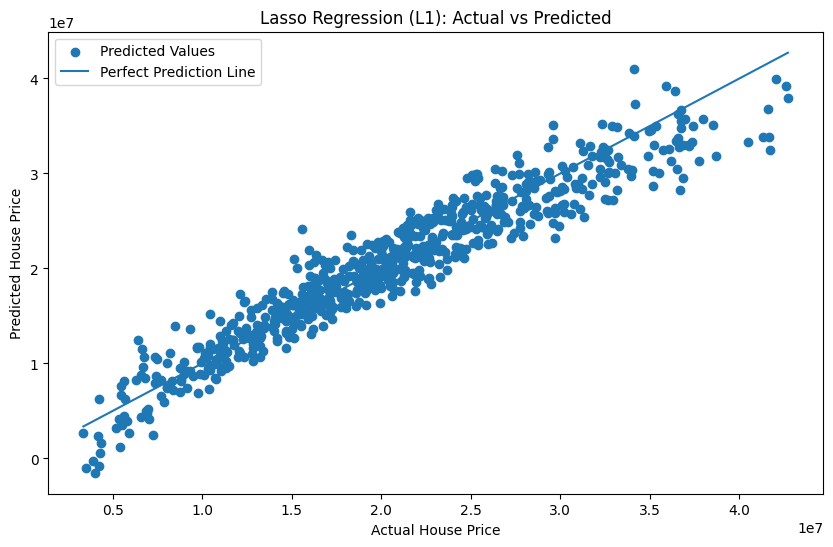

In [38]:


# =====================================
# Lasso Regression Final Graph
# =====================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    p_test_l,
    label='Predicted Values'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    label='Perfect Prediction Line'
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Lasso Regression (L1): Actual vs Predicted")

plt.legend()

plt.show()

## Lasso Regression (L1) Graph Interpretation

### Graph Analysis: Actual vs Predicted House Price

The graph above represents the relationship between the **actual house prices** and the **predicted house prices** generated by the Lasso Regression (L1) model.

### Observation

- Most prediction points are positioned close to the **Perfect Prediction Line**.
- The prediction values follow a strong positive trend with the actual values.
- Small deviations from the diagonal line indicate minor prediction errors.
- The model shows a consistent prediction pattern across different house price ranges.

### Interpretation

Lasso Regression applies **L1 regularization**, which helps reduce model complexity and performs automatic feature selection. The graph indicates that the model captures the relationship between input features and house prices effectively.

### Conclusion

✅ Predictions closely follow actual values  
✅ Low prediction error observed  
✅ Very low overfitting detected  
✅ Strong generalization capability  
✅ Stable performance across different data points  

Therefore, the **Lasso Regression (L1) model can be considered a good and reliable model for house price prediction**.

# Final Conclusion – Lasso Regression

| Metric | Value | Interpretation |
|----------|--------|----------------|
| Training R² Score | 91.45% | Model learned training data effectively |
| Testing R² Score | 91.02% | Strong prediction performance on unseen data |
| Average Cross Validation Score | 91.29% | Stable and reliable model performance |
| MAE | 1,876,064.29 | Average prediction error |
| MSE | 5,861,971,810,920.05 | Squared prediction error |
| Train-Test Difference | 0.42% | Extremely small difference indicates excellent generalization |
| Model Performance | Excellent |
| Overfitting Status | Very Low |

## Model Status

✅ Good Model  
❌ Worst Model: No

## Final Business Conclusion

The Lasso Regression model achieved a training score of **91.45%** and a testing score of **91.02%**. The average cross-validation score of **91.29%** indicates stable and consistent performance across multiple folds. The difference between training and testing scores is only **0.42%**, which shows very low overfitting and excellent generalization ability. Therefore, the Lasso Regression model can be considered a reliable and effective model for house price prediction on unseen data.